# Cavity number preprocessing
Students should develop a software program to preprocess an image and get it ready to perform the
OCR of the cavity number of a plastic cap.
The cap has an external tab at a fixed position in relation to the cavity number.

## Task 0: Imports and setup

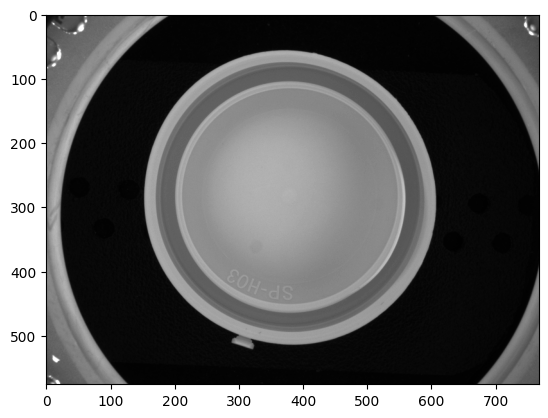

In [19]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import sys

# Only for jupyter notebook visualization
%matplotlib inline 

WARP_COEFF = 3.5
BINARY_TRESHOLD = 20
ANNULAR_REGION_SIZE = 15

path="./img/d_02.bmp"
filename = path.split("/")[-1]
image = cv2.imread(path, cv2.COLOR_BGR2GRAY)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.show()

## Task 1: Generate a crop of the cavity number
### 1.1: Outline the cap by generating a circle that fits the cap mouth

#### 4) WORKING SOLUTION Delete objects around 

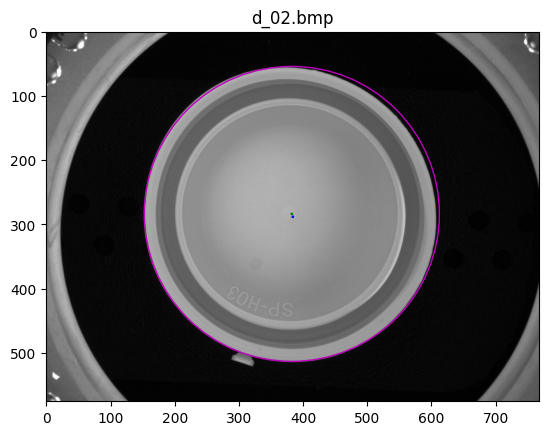

In [ ]:
_, image_bin = cv2.threshold(image, BINARY_TRESHOLD, 255, cv2.THRESH_BINARY)

edge_detected_image = image_bin - cv2.erode(image_bin, np.ones((3,3), np.uint8))

middle_line = edge_detected_image[:, int(edge_detected_image.shape[1]/2)]

# nonzero returns an array for each dimension of the input array, middle line is monodimensional so we take the first
non_zero_indices = np.nonzero(middle_line)[0]

# we take as diameter the distance between the farthest nonzero (fg) pixels among the middle line 
diameter = non_zero_indices[-1]-non_zero_indices[0]
radius = int(diameter/2)
rows = image.shape[0]

found = False
par2 = 20

# it may happen that HoughCircles does not detect circles so we iteratively decrease its param 2
# the smaller this param is and more "false positives" HoughCircles will find 
while not found and par2 > 5:
    circles = cv2.HoughCircles(edge_detected_image, 
                            cv2.HOUGH_GRADIENT, # detection method unique that is implemented
                            1, # every pixel has an accumulator
                            rows/4, # minimum distance between centers
                            param1=500, # threshold used for the internal call to Canny edge detector 
                            param2=par2, # threshold that is used with the accumulator array
                            minRadius=int(radius*0.9), # limit the HoughCircles search
                            maxRadius=int(radius*1.1))
    if circles is not None and len(circles) > 0:
        found = True
    par2 -= 5

ax = plt.subplot(1,1,1)
ax.set_title(filename)
if circles is not None:
    if len(circles[0]) > 1:
        print(f"Image {filename} has 2 or more circles")

    # HoughCircles returns a triple nested array of circles, we are interested in the internal list of lists
    for circle in circles[0]:
        center = [circle[0], circle[1]]
        radius = circle[2]
        circle = plt.Circle(center, radius, color='m', fill=False)
        circle_center = plt.Circle(center, 1, color='g', fill=False)
        img_center = plt.Circle([image_bin.shape[1]/2, image_bin.shape[0]/2], 1, color='b', fill=True)

        ax.add_patch(circle)
        ax.add_patch(circle_center)
        ax.add_patch(img_center)

else:
    print(f"Image {filename} has no circles") 

ax.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.show()

### 1.2 Generate a crop containing the cavity number. The crop should contain the cavity number and it should appear upright

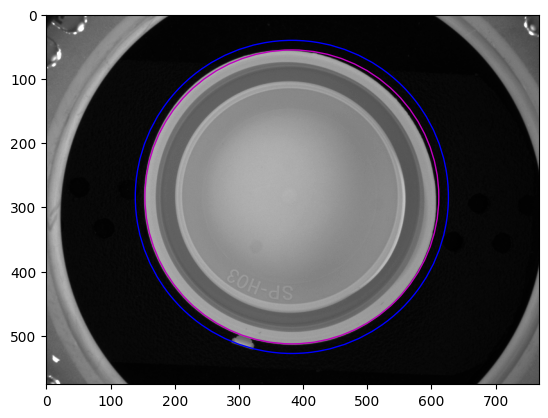

In [21]:
radius_inside = int(radius)
radius_outside = radius_inside + ANNULAR_REGION_SIZE

# visualization of the annular region
fig,ax = plt.subplots(1)
circle_inside = plt.Circle(center, radius_inside, color='m', fill=False)
circle_ouside = plt.Circle(center, radius_outside, color='b', fill=False)
ax.add_patch(circle_inside)
ax.add_patch(circle_ouside)
ax.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.show()

In the following section we isolate the connected component which represents the tab 

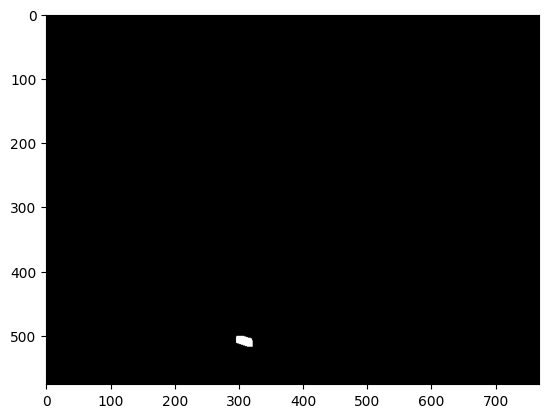

In [22]:
# using the ceil we obtain a slightly larger radius, this helps to get less spurious pixels in the annular region
radius_inside = int(np.ceil(radius))
center = (int(center[0]), int(center[1]))

# create a mask with the same dimensions as the image
mask = np.zeros(image_bin.shape[:2], dtype=np.uint8)

# draw a transparent circle on the mask
cv2.circle(mask, center, radius_outside, (255), thickness=-1)
# draw a black circle on the mask
cv2.circle(mask, center, radius_inside, (0), thickness=-1)

# extract the circular ROI using the mask
circular_roi = cv2.bitwise_and(image_bin, image_bin, mask=mask)

# filter to delete some white areas that are not the tab
# an alternative to median filtering could be to remove those connected components 
# that do not exceed a certain size, they could be e.g. spurious nonblack pixels 
# that may be an obstacle for further elaborations
# circular_roi_median = cv2.medianBlur(circular_roi, 11)
# in the end we chose not to use the median blurring in favor of the more efficient opening 

circular_roi_opened = cv2.morphologyEx(circular_roi, cv2.MORPH_OPEN, np.ones((5,5), np.uint8), iterations=2)

# Display the original image and the circular ROI
fig,ax = plt.subplots(1)
circular_roi_rgb = cv2.cvtColor(circular_roi_opened, cv2.COLOR_BGR2RGB)
ax.imshow(circular_roi_rgb)
plt.show()

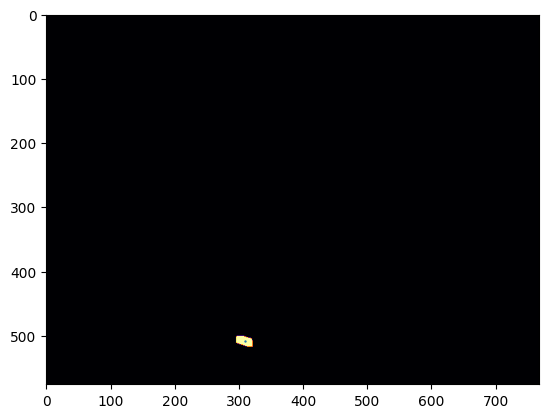

In [23]:
# indices in the stats array
WIDTH = 2
HEIGHT = 3
AREA = 4

# connected component with stats
num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(circular_roi_opened)

# if there are more than 2 connected component search for the one with the higher rectangularity
if len(centroids) > 2:
    print(f"Found {len(centroids) - 1} object in the anular region, they are too much")
    
    best_i = -1
    best_rect = 0

    # the residual object are the tab and some arc region that is too big to be removed with the opening
    # we can find the tab looking at the most rectangular object 
    for i, stat in enumerate(stats[1:]): # alternative to rectangularity: [x for x in stats[1:] if x[AREA] > SOME_THRESHOLD]
        rect = stat[AREA] / (stat[WIDTH] * stat[HEIGHT])
        if rect > best_rect:
            best_rect = rect
            best_i = i+1 # we start from one to skip the background
    centroids = [centroids[0], centroids[best_i]] # keep the backgroud only to be compliant with following code 
elif len(centroids) < 2:
    print("Tab not found!")
    sys.exit(1)

# 0 is the backgorud, 1 is the tab
tab_center = centroids[1]

# inferno to get the black background
plt.imshow(labels_im, cmap="inferno")
plt.scatter(tab_center[0], tab_center[1], s=0.5)

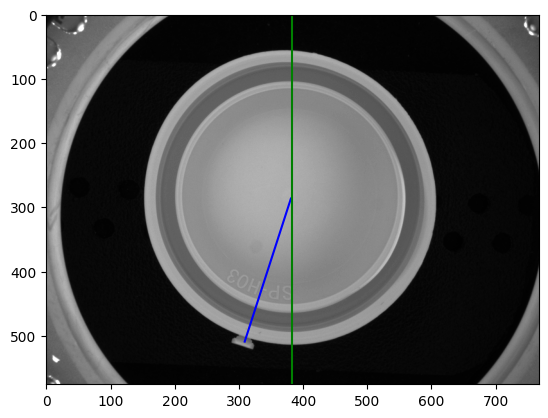

In [24]:
tab_center = np.int32(np.round(tab_center))

# slope of the straight line that connects the center of the tab with the center of the cap
m = (center[1] - tab_center[1]) / (center[0] - tab_center[0]) * 1.0
# intercept
q = center[1] - m * center[0]

# only for display purposes
line = np.polynomial.polynomial.polyline(q, m)

x_val = ([*range(tab_center[0],center[0])] , [*range(center[0], tab_center[0])])[int(tab_center[0] > center[0])]
y_val = np.polynomial.polynomial.polyval(x_val, line)

fig,ax = plt.subplots(1)
ax.imshow(image, cmap='gray', vmin=0, vmax=255)
ax.plot(x_val, y_val, color="b")
ax.plot(np.ones(image.shape[0]-1)*center[0],[*range(1, image.shape[0])], color="g")
plt.show()

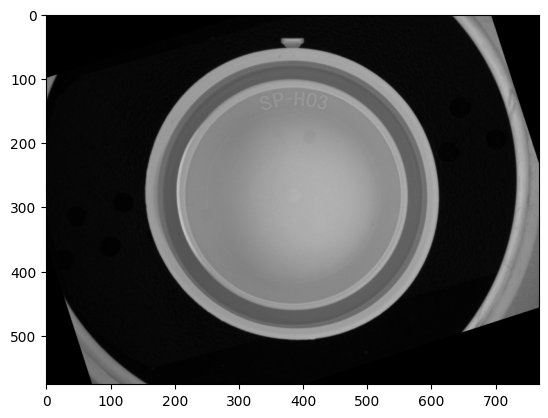

In [ ]:
# find the angle between the line that connects the center of the tab and the center of the cap (blue) and the vertical line passing through the center of the cap (green)
dx = np.abs(tab_center[0]-center[0])
dy = np.abs(tab_center[1]-center[1])

teta = np.arctan(dx/dy)

# from rad to deg
rotation = (teta * 180 / np.pi)

# looking at the slope we choose the direction of the rotation
if m > 0 :
    rotation = rotation * -1

# looking at the tab position we choose if we have to overturn
# tab_center and center is 1 because i use the y value
if tab_center[1] > center[1]:
    rotation += 180

rot_mat = cv2.getRotationMatrix2D(np.asarray(center, dtype=np.float32), rotation, 1.0)
image_with_vertical_tab = cv2.warpAffine(image, rot_mat, image.shape[1::-1])
fig,ax = plt.subplots(1)
ax.imshow(image_with_vertical_tab, cmap='gray', vmin=0, vmax=255)
plt.show()

First naive cropping using a fixed area defined by pixel intervals

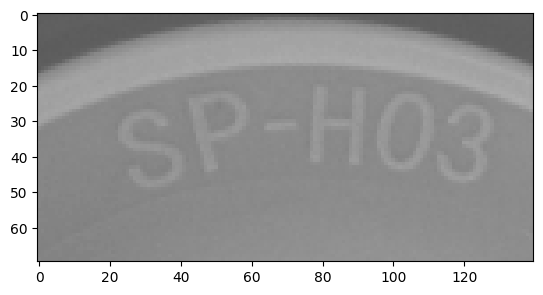

In [26]:
cavity_numer_crop = image_with_vertical_tab.copy()[100:170, 310:450]
plt.imshow(cavity_numer_crop, cmap='gray', vmin=0, vmax=255)
plt.show()

More robust cropping based on radius

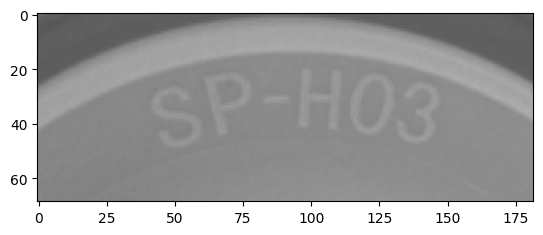

In [27]:
cavity_numer_crop = image_with_vertical_tab.copy()[center[1] - int(radius*0.8) : center[1] - int(radius*0.5), center[0] - int(radius*0.4) : center[0] + int(radius*0.4)]
plt.imshow(cavity_numer_crop, cmap='gray', vmin=0, vmax=255)
plt.show()

In this block we extrapolate the coordinates of the four corners

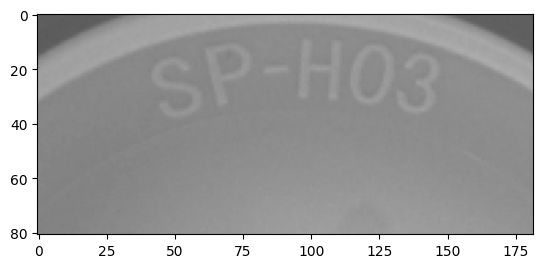

In [28]:
# crop edges definition
top_height = int(center[1]) - int(radius*0.75)
bottom_height = int(center[1]) - int(radius*0.4)
left_width = int(center[0]) - int(radius*0.4)
right_width = int(center[0]) + int(radius*0.4)

# coordinates of the corners
top_left = [top_height, left_width]
bottom_left = [bottom_height, left_width]
top_right = [top_height, right_width]
bottom_right = [bottom_height, right_width]

cavity_numer_crop = image_with_vertical_tab[top_height : bottom_height, left_width : right_width]

plt.imshow(cavity_numer_crop, cmap='gray', vmin=0, vmax=255)
plt.show()

The cavity number may seem to be not centered inside the crop, this is due to the subsequent warping of its corners in a polar image where the dimensions are stretched

## 2 Apply a polar transform

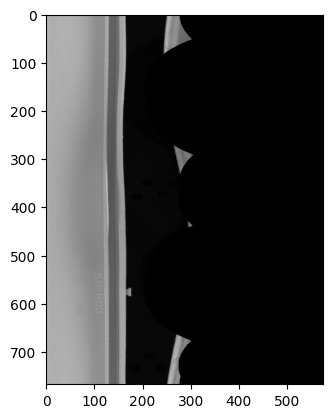

In [37]:
# warp radius is one of the factors that define where the points of the original image will end up in the warped image,
# the higher the radius, the more of the original image will be included in the warped one
warp_radius = WARP_COEFF*radius
flags = cv2.WARP_FILL_OUTLIERS | cv2.WARP_POLAR_LINEAR

polar_image = cv2.warpPolar(image_with_vertical_tab, image_with_vertical_tab.shape, np.asarray(center, dtype=np.float32), warp_radius, flags)

plt.imshow(polar_image, cmap='gray', vmin=0, vmax=255)
plt.show()

Image rotation

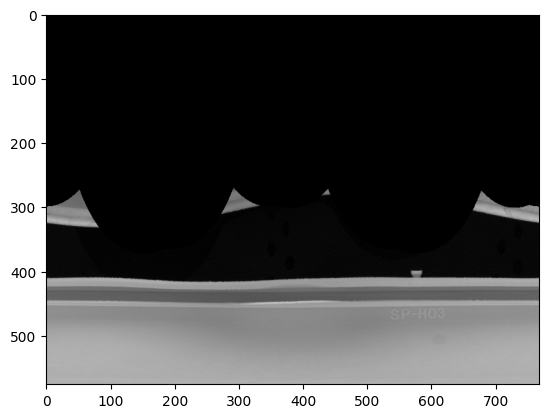

In [30]:
rotated_polar_image = cv2.rotate(polar_image, cv2.ROTATE_90_COUNTERCLOCKWISE)
plt.imshow(rotated_polar_image, cmap='gray', vmin=0, vmax=255)
plt.show()

## 3. Obtain a crop in the rectified image 

#### Initial solution: create image with corners only, apply polar transform, then find the coordinates
This is needed, since cv2.warpPolar() operates with images only

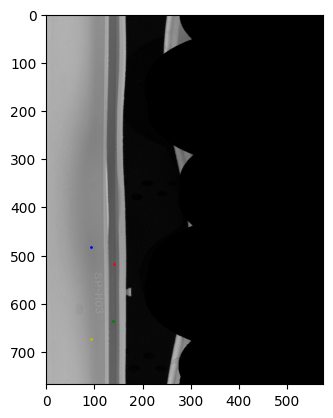

In [35]:
cart_corners = np.asarray([top_left, top_right, bottom_left, bottom_right])

# first, we create an image highlighting crop corners only  
img_wcorners = np.zeros(image_with_vertical_tab.shape)
for i in range(len(cart_corners)):
    img_wcorners[cart_corners[i][0]][cart_corners[0][1]] = 255
    img_wcorners[cart_corners[i][0]][cart_corners[1][1]] = 255
    img_wcorners[cart_corners[i][0]][cart_corners[2][1]] = 255
    img_wcorners[cart_corners[i][0]][cart_corners[3][1]] = 255

# polar transform -> polar image with crop corners
polar_corners= cv2.warpPolar(img_wcorners, image_with_vertical_tab.shape, np.asarray(center, dtype=np.float32), warp_radius, flags | cv2.INTER_CUBIC)

# cart corners are "spread" into several close non-black pixels in the polar image -> find 4 of them
rows_nonzero, cols_nonzero = np.nonzero(polar_corners)

row_indeces = []
col_indeces = []

# finding 4 row indeces
for i, index_row in enumerate(rows_nonzero[1:]):
    if index_row > rows_nonzero[i] + 12:
        row_indeces.append(rows_nonzero[i])

row_indeces.append(rows_nonzero[-1])

# finding col indeces
for i in row_indeces:
    col_indeces.append(np.nonzero(polar_corners[i])[0][0])

# plotting corner points on the polar image
plt.imshow(polar_image, cmap='gray', vmin=0, vmax=255)
colors = ["ob", "or", "og", "oy"]

for i, row_index, in enumerate(row_indeces):
    plt.plot(col_indeces[i], row_index, colors[i], markersize=1)

plt.show()

##### Cropping the number in the rectified image

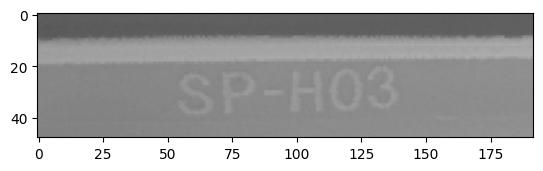

In [36]:
crop_serial = polar_image.copy()[row_indeces[0] : row_indeces[3], col_indeces[0] : col_indeces[1]]
plt.imshow(cv2.rotate(crop_serial, cv2.ROTATE_90_COUNTERCLOCKWISE), cmap='gray', vmin=0, vmax=255)
plt.show()

#### Better solution: warp only the corners defining the bounding box of the crop on the original image
In this solution we manually compute the corrisponding position of the corners defining the crop on the original image, applying this relations (accordingly to OpenCV documentation):

$y\_warp = \dfrac{height}{2\pi} \cdot \theta$

$x\_warp = \dfrac{width}{warp\_radius} \cdot ||I||$

with:

$height$ being the height of the warped image

$\theta$ being the angle that the corner have with the unit vector pointing to the right (0,1) 

$width$ being the width of the warped image

$warp\_radius$ being the radius used while warping the iamge with `cv2.warpPolar()`

$I$ being the vector that starts from the center of the original image and connects to the corner

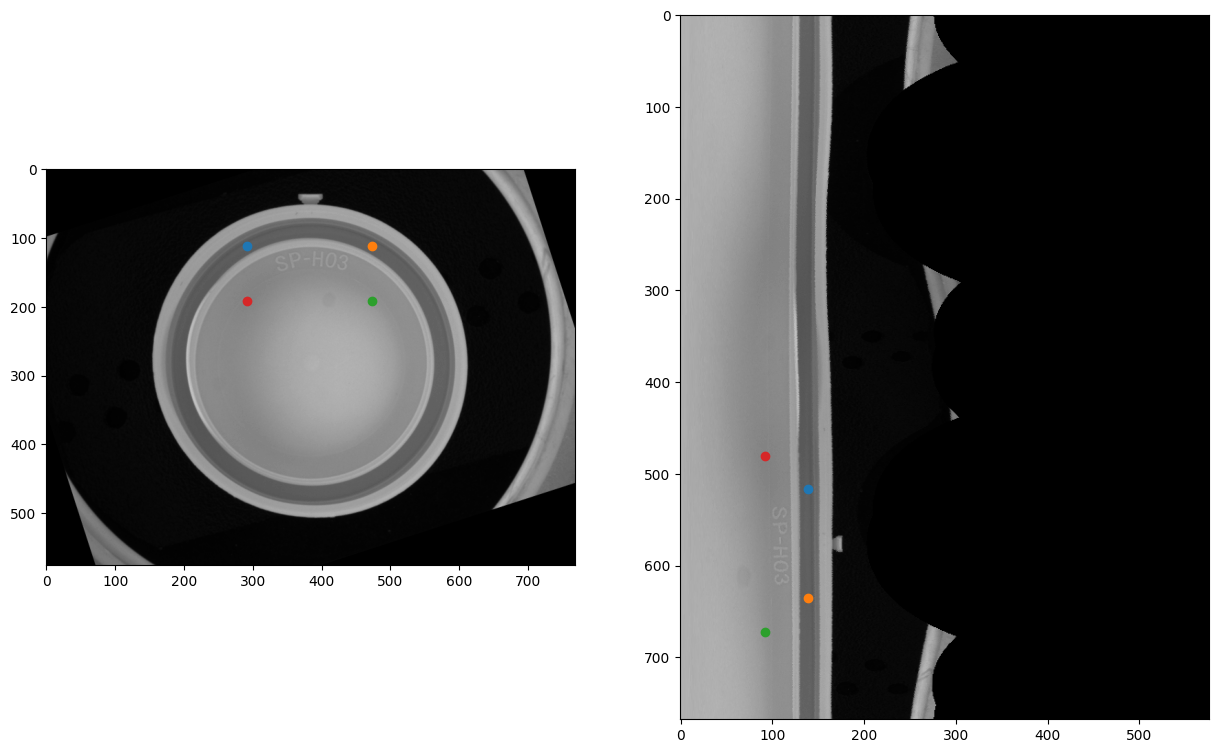

In [33]:
# corners = [top_left, bottom_left, bottom_right, top_right] 
corners = [top_left, top_right, bottom_right, bottom_left]

plt.figure(figsize=(15,15))
ax1 = plt.subplot(1,2,1)

ax1.imshow(image_with_vertical_tab, cmap="gray", vmin=0, vmax=255)
for corner in corners:
    plt.scatter(corner[1],corner[0])

ax2 = plt.subplot(1,2,2)
ax2.imshow(polar_image, cmap='gray', vmin=0, vmax=255)

warped_corners = [[],[]]

for corner in corners:
    x = corner[1]-center[0]
    y = corner[0]-center[1]
    corner_wrt_center = (x,y)
    
    """
    The following line computes the angle between a vector that virtually lies from the center to one of the four corners of the crop
    Since the dot product of two vectors is the product of their norms times the cosine of their angles, if we normalize corner_wrt_center
    to the unit norm and we compute the dot product with the normal vector pointing to the right, we get the cosine of the angle between
    them multiplied by 1^2, aka the cosine of the angle between them. At this point we can take the arccos and get the angle in radians.
    The clipping is due to floating point approximation that could cause the dot product to be slightly above (below) 1 (-1)
    """
    angle = 2*np.pi - np.arccos(np.clip(np.dot(corner_wrt_center / np.linalg.norm(corner_wrt_center), (1, 0)), -1.0, 1.0))

    y_warped = (polar_image.shape[0] / (2 * np.pi)) * angle
    x_warped = ((polar_image.shape[1]*1.0) / warp_radius) * np.sqrt(x**2 + y**2)
    

    warped_corners[0].append(x_warped)
    warped_corners[1].append(y_warped)

    plt.scatter(x_warped, y_warped)

### Final crop of the rectified image

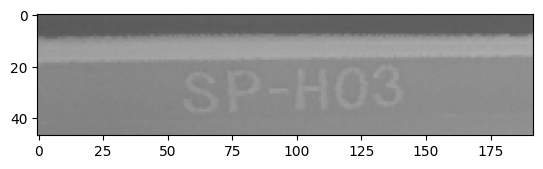

In [34]:
final_crop = cv2.rotate(polar_image[int(min(warped_corners[1])):int(max(warped_corners[1])),int(min(warped_corners[0])):int(max(warped_corners[0]))], cv2.ROTATE_90_COUNTERCLOCKWISE)

plt.imshow(final_crop, cmap="gray", vmin=0, vmax=255)
plt.show()